# L15 worked example: uncertainty and Bayesian optimization on the concrete strength dataset

**scikit-learn** fits the Gaussian process (GP) and the networks, as in Lecture 9:
https://scikit-learn.org.

**Optuna** runs the Bayesian optimization at the end, with its `GPSampler`:
https://optuna.readthedocs.io. Lecture 10 used Optuna with its default sampler; this sampler
also needs `torch`, which Colab already has.

The plan:

1. Three ways to get a 95% prediction interval for the strength of a mix.
2. Check how often each interval contains the measured strength, on two test sets.
3. Use the GP to choose which mixes to test, against choosing them at random.

> Companion notes: [`notes.md`](notes.md).

## Run this first on Colab

Colab starts from its own preinstalled environment rather than this course's `uv`
environment, so run the cell below before anything else. It installs what this
notebook needs and Colab does not already have. Outside Colab it does nothing, so
you can run it or skip it.


In [ ]:
# Run this first on Colab. Anywhere else this cell does nothing.
#
# Only genuinely missing packages are installed, so Colab's own versions of
# everything it already ships are left alone.
import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "optuna": "optuna",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "xlrd": "xlrd",
}


def _missing(module):
    try:
        return importlib.util.find_spec(module) is None
    except ModuleNotFoundError:  # the parent package is absent
        return True


if "google.colab" in sys.modules:
    need = sorted({pip for mod, pip in REQUIREMENTS.items() if _missing(mod)})
    if need:
        print("installing:", " ".join(need))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)
    print("Colab setup done." if need else "Colab: nothing to install.")


## 1. Load the concrete strength dataset, and lock the split

One row per specimen. `groups` numbers the mixes, so that every row of a mix stays on the
same side of a split, exactly as in Lecture 9.

In [2]:
import io
import urllib.request
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA = Path("data")
DATA.mkdir(exist_ok=True)
XLS = DATA / "Concrete_Data.xls"
if not XLS.exists():
    url = "https://archive.ics.uci.edu/static/public/165/concrete+compressive+strength.zip"
    XLS.write_bytes(
        zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read())).read("Concrete_Data.xls")
    )

COLUMNS = ["cement", "slag", "fly_ash", "water", "superplasticizer",
           "coarse_agg", "fine_agg", "age_days", "strength_mpa"]
FEATURES, MIX = COLUMNS[:8], COLUMNS[:7]
concrete = pd.read_excel(XLS)
concrete.columns = COLUMNS
X = concrete[FEATURES].to_numpy()
y = concrete["strength_mpa"].to_numpy()
groups = concrete.groupby(MIX).ngroup().to_numpy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42,
)
train, test = next(splitter.split(X, y, groups))
print(f"{len(train)} training rows, {len(test)} test rows")

835 training rows, 195 test rows


## 2. The aleatoric floor: replicate specimens

Some settings (the same mix at the same age) were tested more than once. Their scatter is
noise no model can predict away.

In [3]:
same = concrete.groupby(FEATURES)["strength_mpa"].agg(["size", "std"])
rep = same[same["size"] > 1]
pooled = np.sqrt((rep["std"] ** 2 * (rep["size"] - 1)).sum() / (rep["size"] - 1).sum())
print(f"{len(rep)} settings tested more than once ({int(rep['size'].sum())} rows): "
      f"pooled scatter {pooled:.2f} MPa")

19 settings tested more than once (53 rows): pooled scatter 5.01 MPa


## 3. Three intervals

- `gp_model()` is Lecture 9's GP: a scaler, then a GP with one length scale per input and a
  noise term (`WhiteKernel`). `predict(X, return_std=True)` returns the mean and the standard
  deviation, which includes the noise.
- `net(seed)` is Lecture 9's network, one hidden layer of 16 tanh units, started from `seed`.
- `intervals(train, test)` fits all three methods on the training rows and returns, for each, the
  centre and the half-width of the 95% interval on the test rows. For split conformal it first
  sets aside a quarter of the training mixes to calibrate the width.

In [4]:
def gp_model():
    return make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=ConstantKernel(1.0) * RBF(np.ones(8), (1e-2, 1e3)) + WhiteKernel(1e-1, (1e-5, 1e1)),
            normalize_y=True,
            random_state=0,
            n_restarts_optimizer=2,
        ),
    )


def net(seed):
    return make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(16,),
            activation="tanh",
            solver="lbfgs",
            max_iter=5000,
            random_state=seed,
        ),
    )


def intervals(tr, te, alpha=0.05):
    out = {}
    gp = gp_model().fit(X[tr], y[tr])
    mu, sd = gp.predict(X[te], return_std=True)
    out["Gaussian process"] = (mu, 1.96 * sd)

    preds = np.array([net(s).fit(X[tr], y[tr]).predict(X[te]) for s in range(5)])
    out["ensemble spread"] = (preds.mean(0), 1.96 * preds.std(0))

    fit_i, cal_i = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
                        .split(X[tr], y[tr], groups[tr]))
    fit_i, cal_i = tr[fit_i], tr[cal_i]
    nets = [net(s).fit(X[fit_i], y[fit_i]) for s in range(5)]
    scores = np.abs(y[cal_i] - np.mean([m.predict(X[cal_i]) for m in nets], 0))
    k = len(scores)
    q = np.quantile(scores, min(1.0, np.ceil((k + 1) * (1 - alpha)) / k), method="higher")
    out["split conformal"] = (np.mean([m.predict(X[te]) for m in nets], 0), np.full(len(te), q))
    noise = np.sqrt(gp[-1].kernel_.k2.noise_level) * gp[-1]._y_train_std
    print(f"  GP noise term {noise:.2f} MPa; conformal calibration rows {k}, q = {q:.2f} MPa")
    return out


def report(tr, te, name):
    print(name)
    for method, (centre, half) in intervals(tr, te).items():
        picp = np.mean(np.abs(y[te] - centre) < half)
        print(f"  {method:18s} coverage {picp:5.0%}   mean width {2 * half.mean():5.1f} MPa")

## 4. Coverage on two test sets

The **grouped split** is Lecture 9's. The **extrapolation split** holds out the 20% of mixes
with the lowest water/cement ratio: the strongest mixes, where a design loop will push.

In [5]:
report(train, test, "grouped split")

wc = (concrete["water"] / concrete["cement"]).groupby(groups).mean()
held = wc[wc <= wc.quantile(0.2)].index
te2 = np.flatnonzero(np.isin(groups, held))
tr2 = np.flatnonzero(~np.isin(groups, held))
print(f"\nheld out: mean strength {y[te2].mean():.1f} MPa; kept: {y[tr2].mean():.1f} MPa")
report(tr2, te2, "extrapolation split")

grouped split


  GP noise term 3.92 MPa; conformal calibration rows 210, q = 13.43 MPa
  Gaussian process   coverage   95%   mean width  20.4 MPa
  ensemble spread    coverage   76%   mean width  12.1 MPa
  split conformal    coverage   96%   mean width  26.9 MPa

held out: mean strength 49.5 MPa; kept: 31.1 MPa
extrapolation split


  GP noise term 2.42 MPa; conformal calibration rows 213, q = 9.05 MPa
  Gaussian process   coverage   89%   mean width  43.8 MPa
  ensemble spread    coverage   86%   mean width  30.9 MPa
  split conformal    coverage   70%   mean width  18.1 MPa


**What to read in the output**

- On the grouped split the GP and conformal intervals cover about 95%. The ensemble's spread
  covers far less: it is the epistemic part only.
- On the strongest mixes every method covers less than it claims. Conformal falls furthest: the
  strong mixes are not exchangeable with its calibration mixes.

## 5. Bayesian optimization of a mix

The "lab" is Lecture 9's GP fitted to all 1,030 rows, standing in for the 28-day test.
`lab(u)` takes designs scaled to $[0, 1]$ for cement, slag, water and superplasticizer, between
the 5th and 95th percentiles of the 28-day mixes, with the other ingredients at their medians.

In [6]:
emulator = gp_model().fit(X, y)
d28 = concrete[concrete.age_days == 28]
fixed = d28[FEATURES].median().to_numpy()
DESIGN = ["cement", "slag", "water", "superplasticizer"]
idx = [FEATURES.index(c) for c in DESIGN]
lo = d28[DESIGN].quantile(0.05).to_numpy()
hi = d28[DESIGN].quantile(0.95).to_numpy()


def lab(u):
    rows = np.tile(fixed, (len(u), 1))
    rows[:, idx] = lo + u * (hi - lo)
    return emulator.predict(rows)


print({c: (round(a), round(b)) for c, a, b in zip(DESIGN, lo, hi)})

{'cement': (141, 475), 'slag': (0, 237), 'water': (152, 216), 'superplasticizer': (0, 16)}


**Expected improvement**, for maximization, with $f^*$ the best strength so far:

$$
\text{EI}(x) = \big(\mu(x) - f^*\big)\,\Phi(z) + \sigma(x)\,\phi(z), \qquad z = \frac{\mu(x) - f^*}{\sigma(x)}
$$

`bo(seed)` starts from 5 random mixes, then 20 times: fits a GP to the mixes tested so far,
scores 4,000 random candidates by EI, and tests the best one. `random_search(seed)` tests 25
random mixes. Both return the best strength found after each test.

seed 0: BO best 91.4 MPa, random best 79.0 MPa
seed 1: BO best 91.5 MPa, random best 87.2 MPa
seed 2: BO best 91.7 MPa, random best 79.8 MPa
seed 3: BO best 91.5 MPa, random best 82.9 MPa
seed 4: BO best 91.3 MPa, random best 89.7 MPa


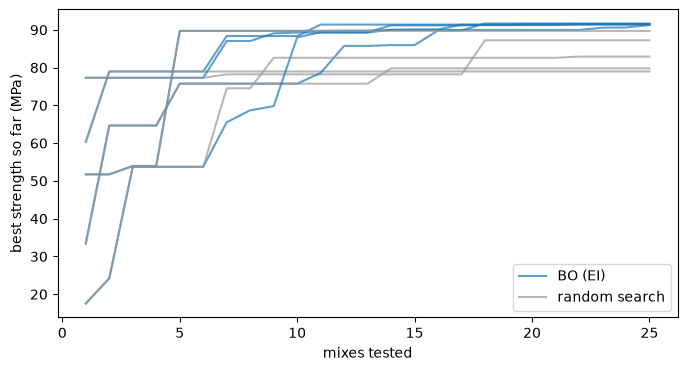

In [7]:
def expected_improvement(mu, sd, best):
    sd = np.maximum(sd, 1e-9)
    z = (mu - best) / sd
    return (mu - best) * norm.cdf(z) + sd * norm.pdf(z)


def bo(seed, n_init=5, budget=25):
    rng = np.random.default_rng(seed)
    U = rng.random((n_init, 4))
    Y = lab(U)
    for _ in range(budget - n_init):
        gp = GaussianProcessRegressor(
            kernel=ConstantKernel(1.0) * Matern(np.ones(4), (1e-2, 1e2), nu=2.5)
            + WhiteKernel(1e-3, (1e-6, 1e-1)),
            normalize_y=True,
            random_state=seed,
        ).fit(U, Y)
        candidates = rng.random((4000, 4))
        mu, sd = gp.predict(candidates, return_std=True)
        best_candidate = candidates[expected_improvement(mu, sd, Y.max()).argmax()]
        U = np.vstack([U, best_candidate])
        Y = np.append(Y, lab(best_candidate[None, :]))
    return np.maximum.accumulate(Y), U[Y.argmax()]


def random_search(seed, budget=25):
    rng = np.random.default_rng(seed)
    return np.maximum.accumulate(lab(rng.random((budget, 4))))


runs_bo = [bo(s) for s in range(5)]
runs_rand = [random_search(s) for s in range(5)]
for s in range(5):
    print(f"seed {s}: BO best {runs_bo[s][0][-1]:.1f} MPa, random best {runs_rand[s][-1]:.1f} MPa")

fig, ax = plt.subplots(figsize=(8, 4))
for s in range(5):
    ax.plot(range(1, 26), runs_bo[s][0], color="C0", alpha=0.7, label="BO (EI)" if s == 0 else None)
    ax.plot(range(1, 26), runs_rand[s], color="0.6", alpha=0.7, label="random search" if s == 0 else None)
ax.set_xlabel("mixes tested")
ax.set_ylabel("best strength so far (MPa)")
ax.legend()
plt.show()

## 6. Check the answer with the uncertainty

The best mix BO found, back in kilograms per cubic meter, with the emulator's 95% interval.

In [8]:
u_best = runs_bo[0][1]
row = fixed.copy()
row[idx] = lo + u_best * (hi - lo)
mean, sd = emulator.predict(row[None, :], return_std=True)
print({c: round(v) for c, v in zip(DESIGN, row[idx])})
print(f"predicted {mean[0]:.1f} +/- {1.96 * sd[0]:.1f} MPa; strongest specimen ever tested {y.max():.1f} MPa")

{'cement': 470, 'slag': 233, 'water': 164, 'superplasticizer': 11}
predicted 91.4 +/- 17.6 MPa; strongest specimen ever tested 82.6 MPa


The optimizer found where the emulator is most optimistic, far from any tested mix, and the
wide interval says so. In a real campaign the next step is to cast that mix and add the result.

## 7. The same search in Optuna

- `trial.suggest_float(name, low, high)` lets the sampler choose a value in the range.
- `optuna.samplers.GPSampler(n_startup_trials=5)` samples 5 mixes at random, then lets a GP with
  an acquisition function choose.

In [9]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    u = np.array([
        (trial.suggest_float(c, a, b) - a) / (b - a) for c, a, b in zip(DESIGN, lo, hi)
    ])
    return float(lab(u[None, :])[0])


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.GPSampler(
        seed=0,
        n_startup_trials=5,
    ),
)
study.optimize(
    objective,
    n_trials=25,
)
print(f"Optuna GPSampler, 25 trials: best {study.best_value:.1f} MPa")
print({k: round(v) for k, v in study.best_params.items()})

Optuna GPSampler, 25 trials: best 92.0 MPa
{'cement': 475, 'slag': 237, 'water': 165, 'superplasticizer': 11}


## Try it

- Change `alpha` in `intervals` to 0.2 and check that the 80% intervals cover about 80% on the
  grouped split.
- Restrict the design box to the middle of the data (25th to 75th percentile). Does BO still
  land on a mix the emulator is unsure about?
- Replace expected improvement with $\mu + 3\sigma$ (an upper confidence bound) in `bo`. Does it
  find the best mix in fewer or more tests?